# FX pairs: what a tree can express that a weighted sum cannot

[`06_linear`](06_linear.ipynb) established two things about this universe. The 20 pairs are
quotes between eight currencies, so the cross-section is dependent - a dollar move appears in
every pair with USD on one side, at the same moment, in the same direction - and a penalty
addresses the collinear feature set while doing nothing about that. Within those limits the
penalty sweep moved the ranking from the wrong side of zero to a thin margin above it.

Gradient boosting changes what can be represented, not what the cross-section is. A linear model
assigns one weight per feature and applies it everywhere; a tree splits on one feature inside a
region defined by another, so it can express "when the dollar is trending, rank on momentum;
otherwise rank on carry" without anyone constructing that column. Whether an exchange-rate cross
section rewards that is the question here, and it is a fair one: currency returns are widely
modelled as regime-dependent, and a regime is exactly a condition on one variable that changes
how another behaves.

Three dials control how far the model goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into,
  and therefore how fine a set of conditions it can express.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Daily exchange-rate
  returns are less heavy-tailed than commodity or crypto returns, which makes this case study
  the useful control on whether the objective matters for the reason the tails suggest.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run.

**A checkpoint is part of a configuration, not a detail of how it was fitted.** Fifteen declared
configurations at ten checkpoints is 150 candidate models, and reporting the leading row of that
table as though it were one experiment would be reporting the maximum of 150 numbers.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say what a tree ensemble can represent that a penalized linear model cannot, and judge from
  the results whether this cross-section rewards it.
- Distinguish a model that ranks a dependent cross-section well from one that has found many
  independent facts.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared FX pairs gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    population_supersedes,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = "23abc9ef1009"

In [3]:
study = open_study("fx_pairs", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The labels are the same ones the linear notebook fitted, and for the same reason: the two
families are compared on identical targets, folds and features, so what separates their results
is the family. Fitting all three horizons here rather than one also carries the linear
notebook's finding forward to be checked - that both the best result a grid reaches and the
number of configurations above zero rise with the prediction horizon.

In [4]:
declared_labels(study, "gbm")

('fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d')

Each label's menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`,
and each resolves to a preset in `case_studies/config/lgb/`. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. It is the dial that decides whether a model can express a condition like "when
  the dollar is trending, rank on momentum; otherwise rank on carry" - a statement about one
  feature that only holds inside a region defined by another.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_1d""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_1d""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_1d""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_1d""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1d""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_5d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. Comparing the loaded rows against the complete declared catalog catches
either knob, and says so here rather than several cells later in a message about hashes.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs, which is not the "
        "complete declared catalog, so it cannot publish the canonical population; pass "
        "POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_huber""",63,20,41260,8,10,2016-01-05,2023-12-28
"""default_mae""",63,20,41260,8,10,2016-01-05,2023-12-28
"""default_mse""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_15_huber""",63,20,41260,8,10,2016-01-05,2023-12-28
"""leaves_15_mae""",63,20,41260,8,10,2016-01-05,2023-12-28
…,…,…,…,…,…,…,…
"""leaves_63_mae""",63,20,41180,8,10,2016-01-05,2023-12-21
"""leaves_63_mse""",63,20,41180,8,10,2016-01-05,2023-12-21
"""leaves_7_huber""",63,20,41180,8,10,2016-01-05,2023-12-21


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Slicing the window and cleaning its rows depends on the data and not on the model, so it is
work several configurations could share. Whether they do depends on how the requests reach the
runner. Handed over unresolved, they go to a batch path that walks folds on the outside and
configurations on the inside, so one prepared fold serves every configuration and only one is
held at a time. Resolved first - as they are here, so that the plan above can be shown against
the real data - each configuration prepares its own. On a cross-section of this size that costs
seconds and buys a plan that can be read before anything is fitted. On a panel large enough
that one prepared fold set does not comfortably fit in memory the trade runs the other way,
which is why the call also accepts requests that have not been resolved.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is the set of
prediction identities, so anything that moves a training identity - a changed estimator
parameter as much as a changed configuration menu - produces a different population under the
same name, and the registry refuses to write it without being told which snapshot it supersedes.
That lineage is the only record of which generation is which.

It defaults to the hash the published population actually superseded, not to empty. The hash is
part of what the snapshot is hashed over, so a run that left it empty would compute a different
population and be refused against the one on record. Carrying the value the published run used
is what lets this notebook re-run and resolve to the population it published rather than to a
new one.

Whether the declared hash may be offered is `population_supersedes`, which every notebook that
publishes a population now shares. It is offered when the declaration names the generation in
force, so a refit publishes the next one, and when it names the generation that one superseded,
so a re-run resolves to the population it published. It is withheld everywhere else: on a
reader's clean clone, where `run_log/` is gitignored and `OfficialPopulation.create` refuses a
first version claiming to supersede something; under a caller's own `POPULATION_NAME`, which has
no prior generation; and in a reduced-scale run, whose isolated registry holds nothing under this
name and whose population is thrown away with the workspace anyway.

**One population covers every label**, because one run fits every label. A population is
immutable once written, so a notebook fitting one label per run under a single name publishes
the first label and is refused for the second; fitting them together is what lets one name
describe the whole declared set.

In [8]:
population_name = POPULATION_NAME or "fx_pairs-gbm-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=population_supersedes(study, name=population_name, declared=SUPERSEDES_POPULATION),
)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 0: training n_train=18,260 n_val=5,160 trees=500 num_leaves=? obj=regression


      fold 0: done in 44s


      fold 1: training n_train=23,420 n_val=5,160 trees=500 num_leaves=? obj=regression


      fold 1: done in 10s


      fold 2: training n_train=25,780 n_val=5,160 trees=500 num_leaves=? obj=regression


...

      fold 6: training n_train=25,700 n_val=5,160 trees=500 num_leaves=63 obj=huber


      fold 6: done in 1s


      fold 7: training n_train=25,700 n_val=5,060 trees=500 num_leaves=63 obj=huber


      fold 7: done in 1s


45 configurations fitted
population fx_pairs-gbm-validation-v1: 450 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("fx_pairs", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_1d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the pairs by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by label and then by IC, and the top of each label's block is the trap this
notebook exists to describe. The leading row for a label is the maximum of 150 numbers - fifteen
configurations at ten checkpoints each. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

Coverage is judged against each label's own maximum number of scorable validation dates. The
horizons do not offer the same number to begin with, since a longer forward window runs out
earlier, so one global maximum would mark whole labels incomplete for a reason unrelated to any
model.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels
# by whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

450 candidate models: 15 configurations
at 10 checkpoints each, on 3 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_ret_1d""","""default_mae""",50,0.003515,0.021225,2063.0,true
"""fwd_ret_1d""","""leaves_7_huber""",50,0.003097,0.030577,2063.0,true
"""fwd_ret_1d""","""leaves_7_huber""",150,0.002567,0.030014,2063.0,true
"""fwd_ret_1d""","""leaves_15_huber""",50,0.002241,0.03075,2063.0,true
"""fwd_ret_1d""","""default_mse""",500,0.001732,0.019553,2063.0,true
…,…,…,…,…,…,…
"""fwd_ret_1d""","""leaves_7_huber""",250,0.000975,0.029858,2063.0,true
"""fwd_ret_1d""","""leaves_15_huber""",100,0.000899,0.030434,2063.0,true
"""fwd_ret_1d""","""leaves_15_mae""",50,0.000889,0.026793,2063.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

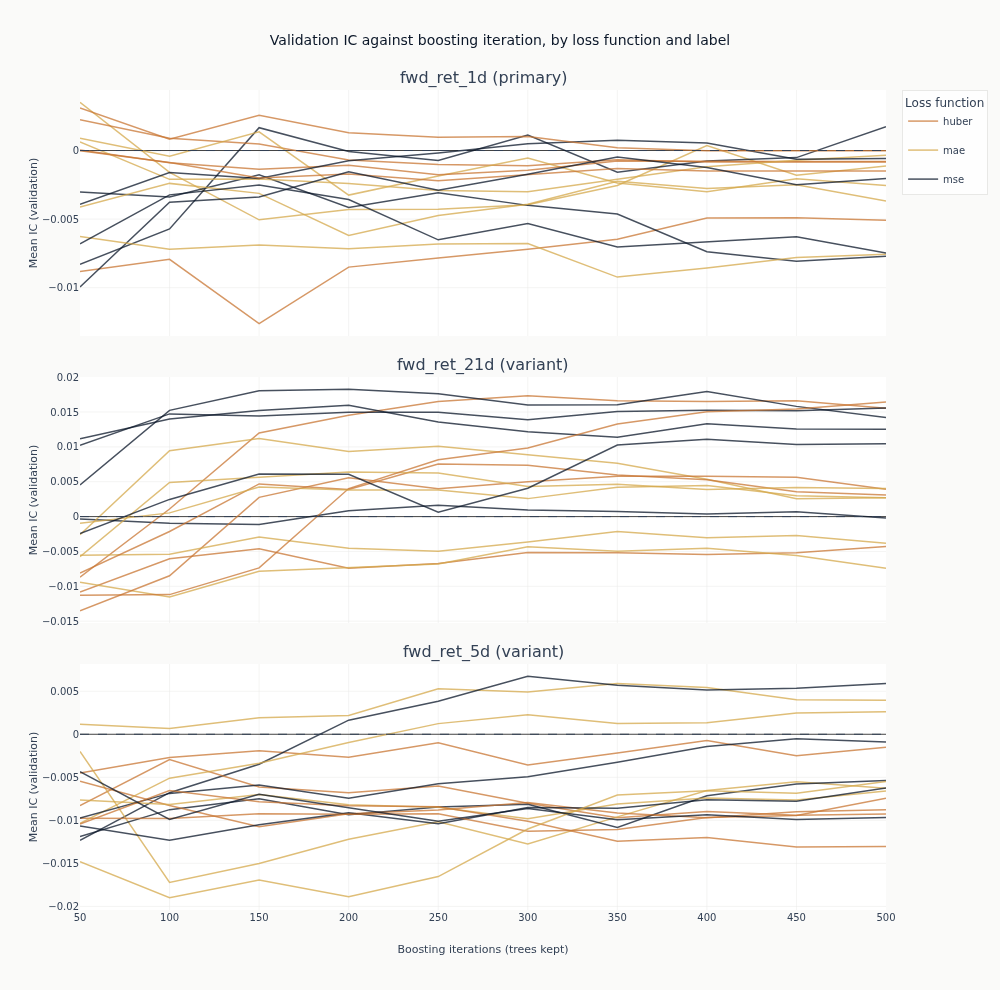

In [10]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
legend_shown: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in panel.get_column("config_name").unique(maintain_order=True):
        series = panel.filter(pl.col("config_name") == config_name)
        objective = objective_of(config_name)
        # One legend entry per loss function, not per configuration: fifteen names repeated
        # down three panels is a legend taller than the chart, and the colour is the only
        # thing the legend has to explain.
        first_of_objective = objective not in legend_shown
        legend_shown.add(objective)
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines",
                name=objective,
                legendgroup=objective,
                showlegend=first_of_objective,
                line=dict(color=objectives[objective], width=1.5),
                opacity=0.75,
            ),
            row=row,
            col=1,
        )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function and label",
    height=330 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Loss function", font=dict(size=10)),
)
show_plotly_with_alt(
    fig_curves,
    "Stacked line charts of mean validation information coefficient against boosting iteration, "
    "one panel per label, with one line per configuration coloured by loss function: "
    "blue for squared error, amber for absolute error, copper for Huber. Each panel carries a "
    "dashed zero line. The lines start spread out at fifty trees and cross each other repeatedly "
    "rather than rising to a common peak and falling away. In the one-day and 21-day panels the "
    "band drifts downwards as trees are added; in the five-day panel it stays where it started. "
    "A few one-day curves are above the zero line at the earliest checkpoints and two are still "
    "above it at the last. Averaged over its five configurations the blue squared-error group "
    "ends lowest in every panel, but individual blue lines are not: one starts at the top of the "
    "21-day panel and another ends above zero there.",
)

Whether the lines trend, and which way, is not something to read off a page of overlapping
curves. The frame below measures it: for each configuration, its IC at the last checkpoint
minus its IC at the first, and whether its best checkpoint is an interior one rather than
either end. A family that is still learning would show positive changes and interior peaks; a
family that is overfitting would show negative changes; a family with nothing to learn would
show changes centred on zero with peaks scattered anywhere.

In [11]:
drift = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        change=pl.col("last_ic") - pl.col("first_ic"),
        interior_peak=pl.col("peak_checkpoint").is_between(
            pl.col("first_checkpoint"), pl.col("last_checkpoint"), closed="none"
        ),
    )
)
trees_effect = (
    drift.group_by("label")
    .agg(
        configurations=pl.len(),
        median_change=pl.col("change").median(),
        ended_lower=(pl.col("change") < 0).sum(),
        interior_peaks=pl.col("interior_peak").sum(),
    )
    .sort("label")
)
trees_effect

label,configurations,median_change,ended_lower,interior_peaks
str,u32,f64,u32,u32
"""fwd_ret_1d""",15,-0.000983,10,7
"""fwd_ret_21d""",15,0.006522,0,12
"""fwd_ret_5d""",15,0.002794,5,6


### Comparing every configuration at the same training length

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

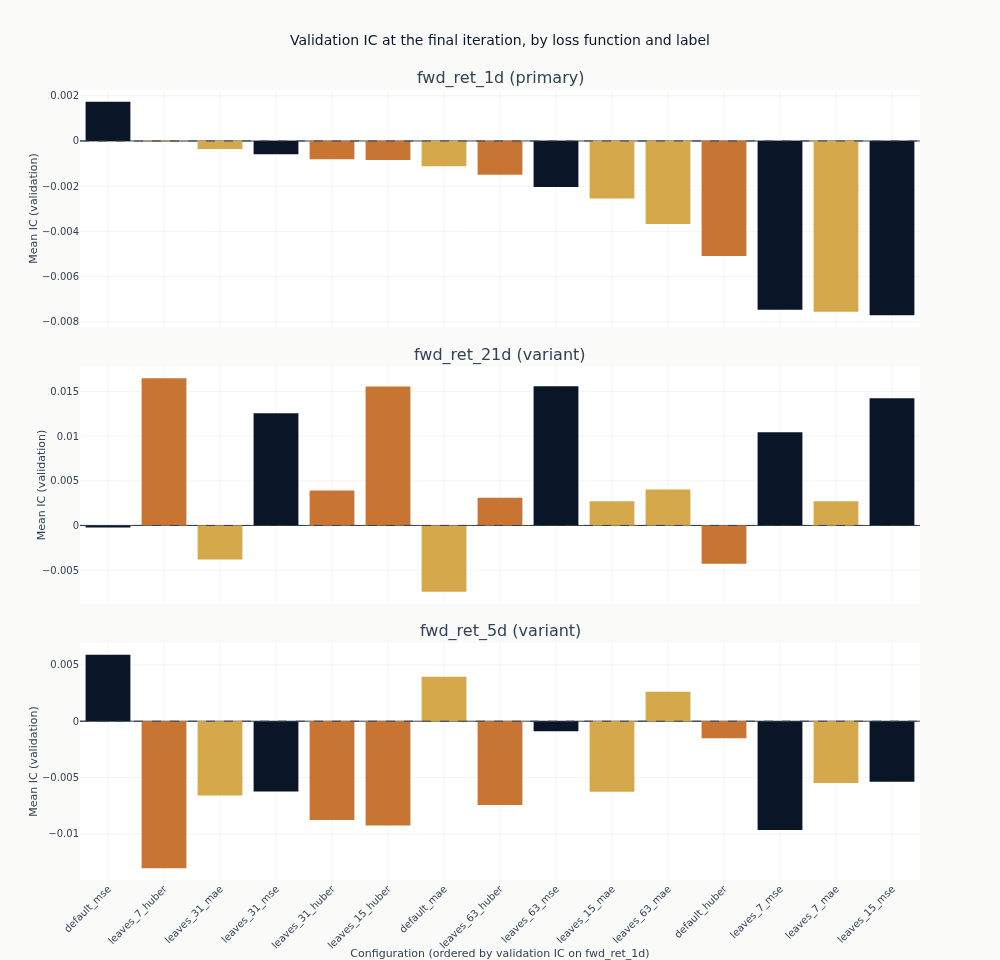

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iteration = int(final.get_column("checkpoint_value").max())
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

fig_obj = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    fig_obj.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[objectives[value] for value in panel.get_column("objective")],
        ),
        row=row,
        col=1,
    )
    fig_obj.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_obj.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_obj.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    tickangle=-45,
    title_text=f"Configuration (ordered by validation IC on {order_label})",
    row=len(panel_labels),
    col=1,
)
fig_obj.update_layout(
    title="Validation IC at the final iteration, by loss function and label",
    height=320 * len(panel_labels),
    width=1000,
    showlegend=False,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_obj,
    "Stacked bar charts of mean validation information coefficient at the final boosting "
    "iteration, one panel per label, coloured by loss function: blue for squared error, amber for "
    "absolute error, copper for Huber. The configurations are in the same order in each panel, "
    f"that order being their ranking on {order_label}, and each panel carries a dashed zero "
    "line. In the one-day panel two amber absolute-error bars clear the line and the other "
    "thirteen hang below it, with the blue squared-error bars longest and grouped at the right of "
    "the order. The 21-day panel puts five bars above the line, three copper Huber, one amber and "
    "one blue. The five-day panel puts two amber bars barely above it and everything else below, "
    "with one squared-error bar far longer than any other in the figure.",
)

### Whether the horizon does here what it did to the linear grid

The question this notebook took from `06_linear`, answered at the same training length for
every configuration. There the best full-coverage IC and the count above zero both rose with
the horizon; the frame below says whether a tree ensemble reproduces that.

In [13]:
horizons = (
    final.group_by("label")
    .agg(
        configurations=pl.len(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort("label")
)
horizons

label,configurations,best_ic,worst_ic,above_zero
str,u32,f64,f64,u32
"""fwd_ret_1d""",15,0.001732,-0.007708,1
"""fwd_ret_21d""",15,0.016454,-0.007405,11
"""fwd_ret_5d""",15,0.005894,-0.013052,3


### Whether the loss function separates them

The colours in the chart above are the claim, so here is the claim as numbers: at the final
iteration, each loss function's mean IC and how many of its configurations finished above zero,
per label. The ordering the heavy-tailed case studies show is Huber highest, absolute error
next, squared error lowest.

In [14]:
objective_summary = (
    final.group_by("label", "objective")
    .agg(
        configurations=pl.len(),
        mean_ic=pl.col("ic_mean").mean(),
        best_ic=pl.col("ic_mean").max(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort(["label", "mean_ic"], descending=[False, True])
)
objective_summary

label,objective,configurations,mean_ic,best_ic,above_zero
str,str,u32,f64,f64,u32
"""fwd_ret_1d""","""huber""",5,-0.001651,-0.00002,0
"""fwd_ret_1d""","""mae""",5,-0.003051,-0.000351,0
"""fwd_ret_1d""","""mse""",5,-0.003213,0.001732,1
"""fwd_ret_21d""","""mse""",5,0.010506,0.015562,4
"""fwd_ret_21d""","""huber""",5,0.006947,0.016454,4
"""fwd_ret_21d""","""mae""",5,-0.000353,0.004026,3
"""fwd_ret_5d""","""mae""",5,-0.002358,0.003958,2
"""fwd_ret_5d""","""mse""",5,-0.003255,0.005894,1
"""fwd_ret_5d""","""huber""",5,-0.008006,-0.001507,0


### What the tails of each label look like

The usual explanation for a loss function changing a rank measure is the tail of the label. A
squared-error fit weights a residual by its square, so one extreme observation moves the fit
more than many ordinary ones; absolute error and Huber do not, and a rank measure does not
reward chasing the extreme. Where that mechanism is at work, the ordering Huber, absolute
error, squared error should be clearest on the heaviest-tailed label.

Excess kurtosis is the direct measurement of that, so it is worth taking before the explanation
is applied rather than after. Zero is the normal distribution; larger means more of the
variance sits in rare large moves.

The label artifact on disk runs to the end of the data, holdout included. Measuring across all
of it would put a statistic computed partly on sealed outcomes into a validation-stage
notebook, so each label's rows are cut at its own `validation_end` - the same development
boundary its fits were resolved against, taken from the plan rather than re-derived. The
boundaries differ by label, and `development_end` in the frame below is where each one falls.

In [15]:
# Each label has its own development boundary, because a longer forward window has to stop
# earlier to keep its outcome inside the development period. One global maximum would cut the
# 21-day label at the one-day label's date and leave decision dates whose forward window ends
# inside the holdout.
development_end = dict(plan.group_by("label").agg(pl.col("validation_end").max()).iter_rows())
tails = pl.DataFrame(
    [
        {
            "label": label,
            "development_end": development_end[label],
            "rows": measured.height,
            "excess_kurtosis": measured.get_column(label).kurtosis(),
        }
        for label in panel_labels
        for measured in [
            pl.read_parquet(study.labels.get(label).path)
            .filter(pl.col("timestamp") <= development_end[label])
            .drop_nulls(label)
        ]
    ]
)
tails

label,development_end,rows,excess_kurtosis
str,date,i64,f64
"""fwd_ret_1d""",2023-12-28,67080,61.350745
"""fwd_ret_21d""",2023-11-29,66680,2.432767
"""fwd_ret_5d""",2023-12-21,67000,9.981319


### How much the checkpoint moves a configuration

One number per configuration and label: the range its IC covers across its own ten checkpoints.
This is the quantity that decides whether choosing a stopping point is a decision worth making
carefully or one being made by noise. A configuration whose IC varies more across its own
training run than the configurations vary among themselves is one where the checkpoint, not the
model, is doing the ranking.

The frame below reduces that to one comparison per label: how far the fifteen configurations
spread at a fixed training length, against how far the median configuration travels across its
own checkpoints. A ratio near one means the two decisions are the same size, and choosing a
checkpoint is as consequential as choosing a model. The five widest-ranging configurations at
each label follow it.

In [16]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort(["label", "checkpoint_range"], descending=[False, True])
)
comparison = (
    final.group_by("label")
    .agg(across_configurations=pl.col("ic_mean").max() - pl.col("ic_mean").min())
    .join(
        spread.group_by("label").agg(within_one_configuration=pl.col("checkpoint_range").median()),
        on="label",
    )
    .with_columns(ratio=pl.col("across_configurations") / pl.col("within_one_configuration"))
    .sort("label")
)
comparison

label,across_configurations,within_one_configuration,ratio
str,f64,f64,f64
"""fwd_ret_1d""",0.00944,0.004607,2.049044
"""fwd_ret_21d""",0.023859,0.012144,1.96474
"""fwd_ret_5d""",0.018946,0.00651,2.910362


In [17]:
spread.group_by("label", maintain_order=True).head(5)

label,config_name,ic_min,ic_max,ic_final,checkpoint_range
str,str,f64,f64,f64,f64
"""fwd_ret_1d""","""default_mse""",-0.008287,0.001732,0.001732,0.01002
"""fwd_ret_1d""","""leaves_63_mse""",-0.009953,-0.000478,-0.002036,0.009475
"""fwd_ret_1d""","""default_mae""",-0.005051,0.003515,-0.001121,0.008566
"""fwd_ret_1d""","""default_huber""",-0.012623,-0.004896,-0.005091,0.007727
"""fwd_ret_1d""","""leaves_15_mse""",-0.008068,-0.001769,-0.007708,0.006299
…,…,…,…,…,…
"""fwd_ret_5d""","""default_mse""",-0.012317,0.006738,0.005894,0.019054
"""fwd_ret_5d""","""leaves_15_mae""",-0.017224,-0.001994,-0.006276,0.01523
"""fwd_ret_5d""","""leaves_7_mae""",-0.018989,-0.005487,-0.005487,0.013503


## 5. What to notice

**Gradient boosting barely clears zero at the traded horizon, and the linear family did.** The
penalty sweep in `06_linear` put ten of twenty-eight one-day configurations above zero; here two
of fifteen end training above it, both by less than two thousandths. This is the first thing to
read carefully, because the ordering is the reverse of what "a more expressive model class"
suggests. Capacity is not free: a tree that can condition one feature on another can also
discover a condition that held in the training window and does not hold after it, and a negative
out-of-sample information coefficient is what a discovered-and-reversed relationship looks like.

**The dependent cross-section is the reason to expect this.** The 20 pairs are quotes among eight
currencies, so much of what there is to find is a single fact - which currencies are strong -
expressed twenty ways. A penalized linear model handles that badly but predictably. A tree
ensemble given the same rows has more ways to fit the particular path that fact took through the
training window, and the extra ways are what fails out of sample. The feature set being collinear
and the cross-section being dependent are different problems, and neither model class addresses
the second.

**More trees do not help, and at two of the three horizons they hurt.** The `trees_effect` frame
is the measurement: at one day and 21 days the median configuration ends below where it started
and two thirds of them end lower, while at five days the median configuration ends where it
started, to five decimal places. What no horizon shows is the shape of a model still learning -
a rise to a peak and a fall away.

`interior_peaks` counts how many configurations reach their best IC somewhere other than the
first or last checkpoint, and it is reported rather than argued from. The ten readings behind
one configuration are not ten independent measurements: checkpoint *k+1* is the same model with
more trees, so a configuration's path is strongly serially correlated, and the position of the
maximum of such a path piles up at the two ends even when there is no trend whatever. Without
knowing what that baseline is for these paths, seven, eight and eight of fifteen is a
description and not evidence either way.

What the drift does support is narrower, and it is not "there is nothing to stop for". Two
thirds of configurations end below where they started at one day and at 21 days, and the median
change is zero at five, so at two of the three horizons a rule that stopped at the first
checkpoint would have beaten training to the last. What that says is that 500 trees is not a
tuned quantity here: the grid fixes the training length so capacity and loss can be compared,
and the comparison is not helped by the extra trees. It does not say a stopping point is
undetectable, and choosing one on these curves would be choosing after seeing the validation
folds - which is exactly why the checkpoint travels into `13_backtest` as part of what gets
selected rather than being resolved here.

**The horizon effect the linear grid showed does not reproduce cleanly here.** `06_linear` had
the best IC and the count above zero both rising across the three horizons. The `horizons` frame
at the final iteration says 21 days is well ahead of the other two on both measures, and that
one day and five days are level with each other - the best five-day configuration is slightly
below the best one-day one, and both put the same number above zero. So the pattern holds at the
long horizon and not in between. One case study with fifteen configurations per label is not
enough to say why; what it does say is that "longer horizons predict better" is not a rule to
carry into the next notebook unexamined.

**Squared error is last at every horizon; which of the other two leads is not stable.** Read
`objective_summary`: by mean IC at the final iteration, `mse` is bottom of all three labels and
only once finishes a configuration above zero. Huber leads at one day and 21 days, absolute
error at five. That much is the ordering the heavy-tailed case studies report, and it is the
part of the loss story this grid supports.

**The tails do not explain it, and this case study is where that shows.** The mechanism usually
offered is that a squared-error fit chases extreme observations, which a rank measure does not
reward, so the penalty should be heaviest on the heaviest-tailed label. The `tails` frame says
the one-day label has by far the heaviest tails of the three - aggregating a return over a longer
window averages its extremes away - yet the gap between the best and worst objective is widest at
five days and narrowest at 21. The ordering survives; its size does not track tail weight in the
direction the mechanism predicts. Fitting three horizons of one case study in one run is what
makes that checkable, because the features, the folds and the universe are held fixed and only
the label moves. Settling it needs a comparison this grid does not run - the same label with its
tails trimmed - so it is recorded as an open question rather than answered.

**The checkpoint is a decision of the same order as the model.** The comparison frame puts the
spread across fifteen configurations at fixed training length against the median configuration's
own range across its ten checkpoints. The first is larger, by a factor between about one and
three depending on the label. That is not the comfortable answer. A ratio near one, which the
21-day label is close to, means choosing where to stop matters nearly as much as choosing which
model to fit - and the stopping point is chosen after seeing the validation folds, while the
model is not.

**A near-zero negative is a weaker statement than a large negative.** In a case study where the
model reliably ranks the cross-section backwards, that is a relationship with the sign fitted the
wrong way, and it is informative. Here the magnitudes are small enough that the honest summary is
that this family does not rank this cross-section, in either direction, rather than that it
reliably gets it wrong.

**None of this selects anything.** IC measures whether predictions rank pairs correctly, not
whether a strategy trading them makes money after costs. Selection is on validation backtest
Sharpe over the population just published, in [`13_backtest`](13_backtest.ipynb), where the
checkpoint is part of what is selected. A family that does not clear zero on IC enters that
comparison without a ranking advantage to defend, which is a fact about this notebook and not a
conclusion about the backtest.

**Known limitations.** The IC is an average of daily rank correlations with no adjustment for the
dependence between pairs that share a currency, which is exactly the structure described above -
so the effective number of independent observations behind each daily correlation is smaller than
the number of pairs. The five-day and 21-day labels add a second dependence the one-day label
does not have: consecutive decision dates share most of their forward window, so their daily
correlations are not independent draws. The grid varies capacity and loss at a fixed learning
rate, and five configurations per objective is a thin base for the objective comparison. And
every number is measured on validation folds already read many times by the time a case study
reaches this notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. Two model classes have now been fitted to this cross-section, and the useful
thing to watch is whether a third fails in the direction the tree ensemble did, which would point
at the cross-section rather than at any one model.